# Oppgave 3

## a)

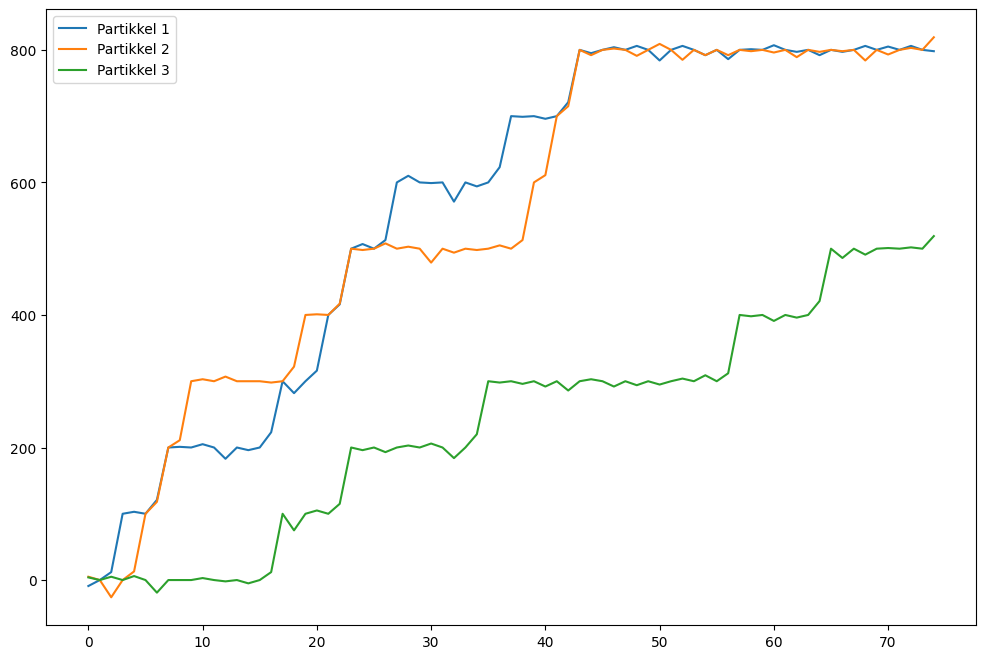

In [101]:
#Importerer nødvendige biblioteker
import numpy as np
import matplotlib.pyplot as plt
import scipy
import random

#Setter opp plotteparametere
plt.rcParams['figure.figsize'] = [12, 8]  # Width, Height in inches


# Sannsynlighetstettheter for steg til høyre, venstre og ingen steg.
def p_plus(x, V):
    return 1/(1+np.exp(-beta*(V(x-h)-V(x+h))) + np.exp(-beta*(V(x)-V(x+h))))

def p_null(x, V):
    return 1/(1+np.exp(-beta*(V(x-h)-V(x))) + np.exp(-beta*(V(x+h)-V(x))))

def p_minus(x, V):
    return 1/(1+np.exp(-beta*(V(x+h)-V(x-h))) + np.exp(-beta*(V(x)-V(x-h))))

beta = 1000
delta_t = 1 # Tidssteg lengde
h = 1 # Steg lengde
timeCycle = 75
number_of_particles = 3
N_x = 100
T_p = 200
k_even = 1
k_odd = 1
alpha = 0.1
bin_size = int(2* np.cbrt(N_x)) # Antall bins i histogrammet

def V_even(x):
    return k_even

def V_odd(x):
    x_mod = x % N_x
    if x_mod < alpha * N_x:
        return k_odd * x_mod / (alpha*N_x)
    else:
        return k_odd * (N_x - x_mod) / ((1 - alpha)*N_x)


# Funksjon for random walk simulasjon i ratchet potensial
def sim2(T_p, N_x):
    x =  np.zeros((timeCycle, number_of_particles)) # Array med alle partikklene i posisjon x=0, iterer gjennom partikler og tidssteg
    X =  np.zeros((timeCycle, number_of_particles))
    for k in range(0, timeCycle, delta_t):
        """ V = lambda x: V_odd(x) """
        if k % 2 == 0:
            V = lambda x: V_even(x)
        else:
            V = lambda x: V_odd(x)

        for i in range(0, T_p, delta_t):
            for j in range(number_of_particles):
                a = random.uniform(0, 1) # Trekker fra std norm fordeling og flytter partikkel tilsvarende
                if a <= p_minus(x[k][j], V):
                    x[k][j] -= h 
                elif (1 - p_plus(x[k][j], V)) < a:
                    x[k][j] += h

                if (1 - p_plus(X[k][j], V)) < a:
                    X[k][j] += h 
                elif a <= p_minus(X[k][j], V):
                    X[k][j] -= h 

                if x[k][j]  == -N_x -h:
                    x[k][j] = N_x
                elif x[k][j] == N_x + h:
                    x[k][j] = -N_x

                if i == T_p - delta_t and k != timeCycle - delta_t:
                    x[k+1][j] = x[k][j]
                    X[k+1][j] = X[k][j]
    return x, X

x1, X1 = sim2(T_p, N_x)


for i in range(number_of_particles):
    plt.plot(X1[:, i], label=f"Partikkel {i+1}")

plt.legend()
plt.show()




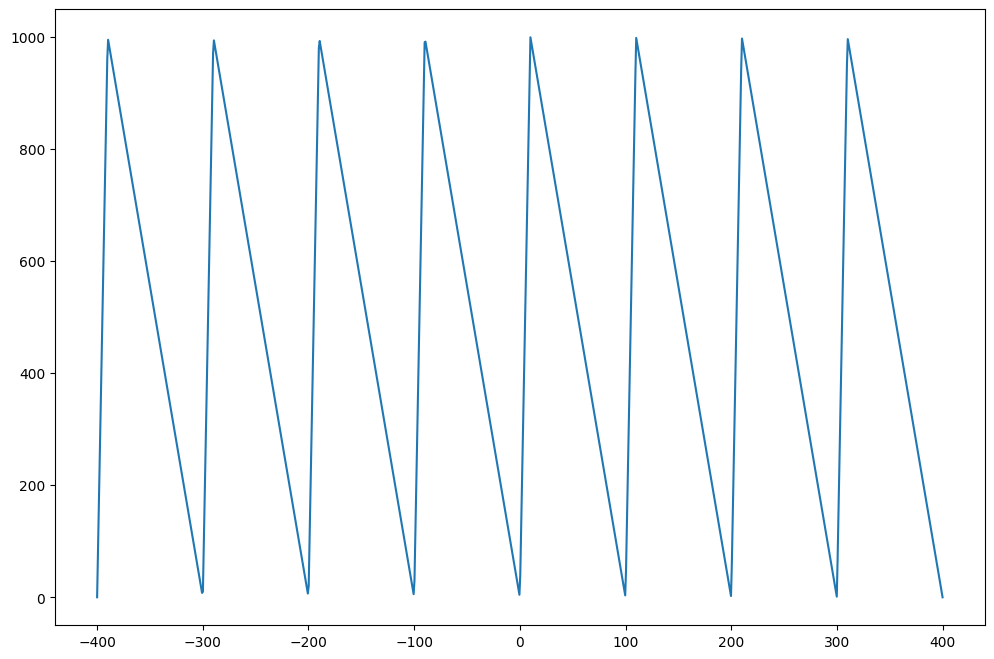

In [87]:
vectorized_potodd = np.vectorize(V_odd)
x = np.linspace(-4*N_x, 4*N_x, 1000)
plt.plot(x, beta*vectorized_potodd(x), label="Potensial med partallskoeffisient")
plt.show()